In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from src.db_utils import load_sql
from src.text_preprocessing import preprocess_text

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

model = joblib.load('../models/logreg_v1.pkl')
vectorizer = joblib.load('../models/tfidf_vectorizer_v1.pkl')

feature_names = vectorizer.get_feature_names_out()

print(f"Количество признаков: {len(feature_names)}")
print(f"Форма коэффициентов модели: {model.coef_.shape}")

Количество признаков: 10000
Форма коэффициентов модели: (3, 10000)


In [11]:
def get_top_words(coefs, feature_names, top_n=20):

    sorted_indices = np.argsort(coefs)[::-1]
    
    top_positive = [(feature_names[i], coefs[i]) for i in sorted_indices[:top_n]]
    
    top_negative = [(feature_names[i], coefs[i]) for i in sorted_indices[-top_n:]][::-1]
    
    return top_positive, top_negative

classes = ['neg', 'neu', 'pos']

for idx, class_name in enumerate(classes):
    print(f"\n{'='*60}")
    print(f"КЛАСС: {class_name.upper()}")
    print('='*60)
    
    coefs = model.coef_[idx]
    top_pos, top_neg = get_top_words(coefs, feature_names, top_n=15)
    
    print("\nТоп-15 слов с ПОЛОЖИТЕЛЬНЫМ весом (увеличивают вероятность класса):")
    for word, weight in top_pos:
        print(f"  {word:20s} {weight:+.4f}")
    
    print("\nТоп-15 слов с ОТРИЦАТЕЛЬНЫМ весом (уменьшают вероятность класса):")
    for word, weight in top_neg:
        print(f"  {word:20s} {weight:+.4f}")


КЛАСС: NEG

Топ-15 слов с ПОЛОЖИТЕЛЬНЫМ весом (увеличивают вероятность класса):
  разочарование        +4.6707
  увы                  +4.3059
  скучный              +4.1960
  отвратительно        +4.0574
  зачем                +3.9696
  худших               +3.8522
  досмотрел            +3.4272
  бред                 +3.4103
  худший               +3.3855
  абсолютно            +3.3277
  откровенно           +3.2922
  слабый               +3.2313
  скучно               +3.2300
  ничего               +3.1909
  разочаровал          +3.1814

Топ-15 слов с ОТРИЦАТЕЛЬНЫМ весом (уменьшают вероятность класса):
  приятно              -4.4391
  отлично              -3.3578
  прекрасно            -3.2434
  однозначно           -3.0484
  слегка               -2.9984
  великолепно          -2.9759
  потрясающе           -2.9266
  несмотря             -2.9011
  отличная             -2.8750
  придраться           -2.8394
  хорош                -2.8068
  отличный             -2.7863
  приятное     

In [12]:
df = load_sql("SELECT * FROM documents")

df['clean_text'] = df['text'].apply(preprocess_text)

df_train, df_val = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df['category']
)

X_train = vectorizer.transform(df_train['clean_text'])
X_val = vectorizer.transform(df_val['clean_text'])

y_train = df_train['category']
y_val = df_val['category']

y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)

df_val = df_val.copy()
df_val['y_true'] = y_val.values
df_val['y_pred'] = y_pred
df_val['confidence'] = y_proba.max(axis=1)

print(f"\nValidation данных: {len(df_val)}")


Validation данных: 26334


In [ ]:
errors = df_val[df_val['y_true'] != df_val['y_pred']].copy()

print(f"Всего ошибок: {len(errors)} из {len(df_val)} ({len(errors)/len(df_val)*100:.1f}%)")

error_types = errors.groupby(['y_true', 'y_pred']).size().reset_index(name='count')
error_types = error_types.sort_values('count', ascending=False)

print("\nТипы ошибок (истинный класс -> предсказанный класс):")
for _, row in error_types.iterrows():
    print(f"  {row['y_true']} -> {row['y_pred']}: {row['count']} раз")

Всего ошибок: 7736 из 26334 (29.4%)

Типы ошибок (истинный класс to предсказанный класс):
  pos to neu: 3328 раз
  neu to pos: 1348 раз
  neu to neg: 1152 раз
  neg to neu: 898 раз
  pos to neg: 794 раз
  neg to pos: 216 раз


In [23]:
pos_to_neu = errors[(errors['y_true'] == 'pos') & (errors['y_pred'] == 'neu')]

print(f"Примеры ошибок pos -> neu (всего {len(pos_to_neu)}):\n")

samples = pos_to_neu.sample(min(10, len(pos_to_neu)), random_state=42)

for idx, row in samples.iterrows():
    print(f"{'='*60}")
    print(f"Истинный класс: {row['y_true']}")
    print(f"Предсказанный: {row['y_pred']}")
    print(f"Уверенность: {row['confidence']:.3f}")
    print(f"\nТекст:\n{row['text'][:300]}...")
    print()

Примеры ошибок pos -> neu (всего 3328):

Истинный класс: pos
Предсказанный: neu
Уверенность: 0.358

Текст:
Когда-то в первых числах апреля для детей был праздник «Книжкины именины» и проводилась масса разных мероприятий. И в ДК приехали пред нами выступать Острецова и Воскресенская. Острецову я знала гораздо лучше, ведь она так здорово писала про собак. Но книжки обеих подаренные нам на той встрече долго...

Истинный класс: pos
Предсказанный: neu
Уверенность: 0.629

Текст:
История существовала всегда – политику придумали люди. Веками человечество корректировало документы и летописи, а в наши дни технологии манипуляции информацией и вовсе достигли уровня прикладного мастерства. Тем милее выглядят на этом фоне идеологически отшлифованные продукты советской эпохи, у кото...

Истинный класс: pos
Предсказанный: neu
Уверенность: 0.351

Текст:
«Трудная мишень» Джона Ву – это, практически, последний фильм с участием Жана-Клода Ван Дамма, при просмотре которого не возникает ощущения, что тебе в

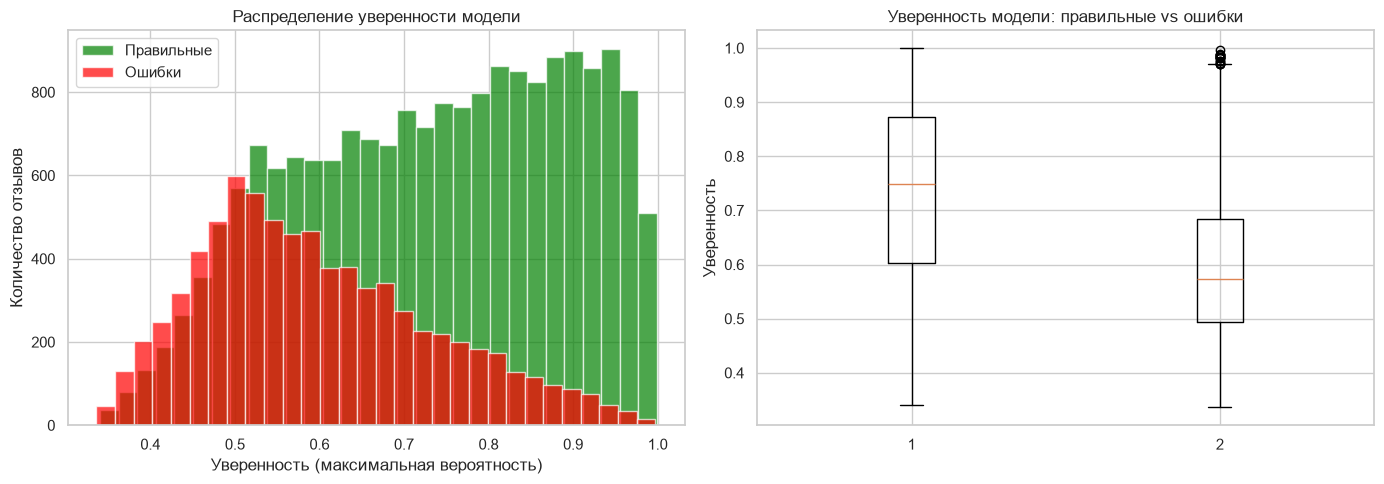


Средняя уверенность:
  Правильные предсказания: 0.734
  Ошибки: 0.597


In [26]:
correct = df_val[df_val['y_true'] == df_val['y_pred']]
wrong = df_val[df_val['y_true'] != df_val['y_pred']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(correct['confidence'], bins=30, color='green', alpha=0.7, label='Правильные')
axes[0].hist(wrong['confidence'], bins=30, color='red', alpha=0.7, label='Ошибки')
axes[0].set_title('Распределение уверенности модели')
axes[0].set_xlabel('Уверенность (максимальная вероятность)')
axes[0].set_ylabel('Количество отзывов')
axes[0].legend()

axes[1].boxplot(
    [correct['confidence'], wrong['confidence']],
    label=['Правильные', 'Ошибки']
)
axes[1].set_title('Уверенность модели: правильные vs ошибки')
axes[1].set_ylabel('Уверенность')

plt.tight_layout()
plt.savefig('../data/processed/confidence_analysis.png', dpi=150)
plt.show()

print(f"\nСредняя уверенность:")
print(f"  Правильные предсказания: {correct['confidence'].mean():.3f}")
print(f"  Ошибки: {wrong['confidence'].mean():.3f}")

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,      # количество деревьев
    max_depth=20,          # максимальная глубина дерева
    random_state=42,
    n_jobs=-1              # использовать все ядра CPU
)

print("Обучаем RandomForest...")
rf_model.fit(X_train, y_train)
print("Обучение завершено!")

rf_pred = rf_model.predict(X_val)

rf_accuracy = accuracy_score(y_val, rf_pred)

print(f"\nRandomForest Accuracy: {rf_accuracy:.4f}")
print("\nОтчёт по классификации:")
print(classification_report(y_val, rf_pred))

Обучаем RandomForest...
Обучение завершено!

RandomForest Accuracy: 0.6628

Отчёт по классификации:
              precision    recall  f1-score   support

         neg       0.89      0.01      0.01      3965
         neu       0.00      0.00      0.00      4941
         pos       0.66      1.00      0.80     17428

    accuracy                           0.66     26334
   macro avg       0.52      0.34      0.27     26334
weighted avg       0.57      0.66      0.53     26334



In [28]:
coef_sum = np.abs(model.coef_).sum(axis=0)
top_indices = np.argsort(coef_sum)[::-1][:1000]

X_train_dense = X_train[:, top_indices].toarray()
X_val_dense = X_val[:, top_indices].toarray()

from catboost import CatBoostClassifier

cb_model = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    verbose=0
)

print("Обучаем CatBoost...")
cb_model.fit(X_train_dense, y_train)
print("Обучение завершено!")

cb_pred = cb_model.predict(X_val_dense).flatten()

cb_accuracy = accuracy_score(y_val, cb_pred)
print(f"\nCatBoost Accuracy: {cb_accuracy:.4f}")
print("\nОтчёт по классификации:")
print(classification_report(y_val, cb_pred))

Обучаем CatBoost...
Обучение завершено!

CatBoost Accuracy: 0.7045

Отчёт по классификации:
              precision    recall  f1-score   support

         neg       0.66      0.32      0.43      3965
         neu       0.49      0.01      0.02      4941
         pos       0.71      0.99      0.83     17428

    accuracy                           0.70     26334
   macro avg       0.62      0.44      0.43     26334
weighted avg       0.66      0.70      0.62     26334

